In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import pandas as pd
import kagglehub
from kagglehub import KaggleDatasetAdapter



/usr/local/python/3.12.1/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# Create data folder if it doesn't exist
os.makedirs("./data", exist_ok=True)

# Download latest version
path = kagglehub.dataset_download("ammaraahmad/us-ecommerce-record-2020")

print("Path to dataset files:", path)

# Path where kagglehub extracted the files
dataset_path = "/home/codespace/.cache/kagglehub/datasets/ammaraahmad/us-ecommerce-record-2020/versions/1"

# Automatically find the first CSV
csv_files = [f for f in os.listdir(dataset_path) if f.endswith('.csv')]
if len(csv_files) == 0:
    raise FileNotFoundError("No CSV file found in the dataset folder!")

csv_file = os.path.join(dataset_path, csv_files[0])

# Load CSV with ISO-8859-1 encoding
ecommerce = pd.read_csv(csv_file, encoding='ISO-8859-1')

# Quick check
print(f"Loaded dataset: {csv_file}")
print("Dataset shape:", ecommerce.shape)
print(ecommerce.head())

Path to dataset files: /home/codespace/.cache/kagglehub/datasets/ammaraahmad/us-ecommerce-record-2020/versions/1
Loaded dataset: /home/codespace/.cache/kagglehub/datasets/ammaraahmad/us-ecommerce-record-2020/versions/1/US  E-commerce records 2020.csv
Dataset shape: (3312, 19)
  Order Date  Row ID        Order ID       Ship Mode Customer ID      Segment  \
0   01-01-20     849  CA-2017-107503  Standard Class    GA-14725     Consumer   
1   01-01-20    4010  CA-2017-144463  Standard Class    SC-20725     Consumer   
2   01-01-20    6683  CA-2017-154466     First Class    DP-13390  Home Office   
3   01-01-20    8070  CA-2017-151750  Standard Class    JM-15250     Consumer   
4   01-01-20    8071  CA-2017-151750  Standard Class    JM-15250     Consumer   

         Country         City       State  Postal Code   Region  \
0  United States       Lorain        Ohio        44052     East   
1  United States  Los Angeles  California        90036     West   
2  United States     Franklin   Wis

In [3]:
# Download dataset
dataset_path = kagglehub.dataset_download("psparks/instacart-market-basket-analysis")
print("Dataset path:", dataset_path)

# -------------------------
# Load small tables
# -------------------------
products = pd.read_csv(os.path.join(dataset_path, "products.csv"))
aisles = pd.read_csv(os.path.join(dataset_path, "aisles.csv"))
departments = pd.read_csv(os.path.join(dataset_path, "departments.csv"))
orders = pd.read_csv(os.path.join(dataset_path, "orders.csv"))

# -------------------------
# Load large tables (limit columns)
# -------------------------
prior = pd.read_csv(
    os.path.join(dataset_path, "order_products__prior.csv"),
    usecols=["order_id","product_id","reordered"]
)

train = pd.read_csv(
    os.path.join(dataset_path, "order_products__train.csv"),
    usecols=["order_id","product_id","reordered"]
)

# Combine
order_products = pd.concat([prior, train], ignore_index=True)

# -------------------------
# SAMPLE to avoid RAM crash
# -------------------------
order_products = order_products.sample(100000, random_state=42)

print("Sampled rows:", order_products.shape)

# -------------------------
# Merge metadata
# -------------------------
products_full = (
    products
    .merge(aisles, on="aisle_id", how="left")
    .merge(departments, on="department_id", how="left")
)

instacart = (
    order_products
    .merge(products_full, on="product_id", how="left")
    .merge(orders, on="order_id", how="left")
)

print("Final dataset shape:", instacart.shape)
print(instacart.head())

Dataset path: /home/codespace/.cache/kagglehub/datasets/psparks/instacart-market-basket-analysis/versions/1
Sampled rows: (100000, 3)
Final dataset shape: (100000, 14)
   order_id  product_id  reordered                 product_name  aisle_id  \
0    740068       21616          0         Organic Baby Arugula       123   
1   1360271       35503          1  Organic Vanilla Almond Milk        91   
2   3211401        5819          1                 Baby Carrots       123   
3   2931112        9387          0          Granny Smith Apples        24   
4   1149035        8277          1     Apple Honeycrisp Organic        24   

   department_id                       aisle  department  user_id eval_set  \
0              4  packaged vegetables fruits     produce   172941    prior   
1             16             soy lactosefree  dairy eggs     5215    prior   
2              4  packaged vegetables fruits     produce   113114    prior   
3              4                fresh fruits     produce 

In [4]:
# Initial Data Exploration
print(ecommerce.head())


  Order Date  Row ID        Order ID       Ship Mode Customer ID      Segment  \
0   01-01-20     849  CA-2017-107503  Standard Class    GA-14725     Consumer   
1   01-01-20    4010  CA-2017-144463  Standard Class    SC-20725     Consumer   
2   01-01-20    6683  CA-2017-154466     First Class    DP-13390  Home Office   
3   01-01-20    8070  CA-2017-151750  Standard Class    JM-15250     Consumer   
4   01-01-20    8071  CA-2017-151750  Standard Class    JM-15250     Consumer   

         Country         City       State  Postal Code   Region  \
0  United States       Lorain        Ohio        44052     East   
1  United States  Los Angeles  California        90036     West   
2  United States     Franklin   Wisconsin        53132  Central   
3  United States   Huntsville       Texas        77340  Central   
4  United States   Huntsville       Texas        77340  Central   

        Product ID         Category Sub-Category  \
0  FUR-FU-10003878        Furniture  Furnishings   
1  FUR

In [5]:
print(instacart.head())

   order_id  product_id  reordered                 product_name  aisle_id  \
0    740068       21616          0         Organic Baby Arugula       123   
1   1360271       35503          1  Organic Vanilla Almond Milk        91   
2   3211401        5819          1                 Baby Carrots       123   
3   2931112        9387          0          Granny Smith Apples        24   
4   1149035        8277          1     Apple Honeycrisp Organic        24   

   department_id                       aisle  department  user_id eval_set  \
0              4  packaged vegetables fruits     produce   172941    prior   
1             16             soy lactosefree  dairy eggs     5215    prior   
2              4  packaged vegetables fruits     produce   113114    prior   
3              4                fresh fruits     produce   138407    prior   
4              4                fresh fruits     produce    78836    prior   

   order_number  order_dow  order_hour_of_day  days_since_prior_orde

In [6]:
# Check missing values
#print(ecommerce.isnull().sum())
#print(instacart.isnull().sum())
ecommerce.describe()
instacart.describe()

,order_id,product_id,reordered,aisle_id,department_id,user_id,order_number,order_dow,order_hour_of_day,days_since_prior_order
count,1.000000e+05,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,93907.000000
mean,1.710178e+06,25541.080270,0.590570,71.271270,9.911490,102966.682740,17.153460,2.736690,13.432680,11.389172
std,9.868847e+05,14118.672224,0.491731,38.232813,6.295034,59328.818004,17.522813,2.096765,4.249763,8.974288
min,3.100000e+01,1.000000,0.000000,1.000000,1.000000,7.000000,1.000000,0.000000,0.000000,0.000000
25%,8.530122e+05,13438.000000,0.000000,31.000000,4.000000,51646.000000,5.000000,1.000000,10.000000,5.000000
50%,1.708670e+06,25256.000000,1.000000,83.000000,9.000000,102563.500000,11.000000,3.000000,13.000000,8.000000
75%,2.564984e+06,37960.750000,1.000000,107.000000,16.000000,154349.000000,24.000000,5.000000,16.000000,15.000000
max,3.421051e+06,49688.000000,1.000000,134.000000,21.000000,206208.000000,100.000000,6.000000,23.000000,30.000000


In [7]:
def has_duplicates(seq):
    # If lengths are unequal, duplicates were removed during set conversion
    return len(seq) != len(set(seq))

print(has_duplicates(instacart))

True


In [8]:
ecommerce.columns

Index(['Order Date', 'Row ID', 'Order ID', 'Ship Mode', 'Customer ID',
       'Segment', 'Country', 'City', 'State', 'Postal Code', 'Region',
       'Product ID', 'Category', 'Sub-Category', 'Product Name', 'Sales',
       'Quantity', 'Discount', 'Profit'],
      dtype='str')

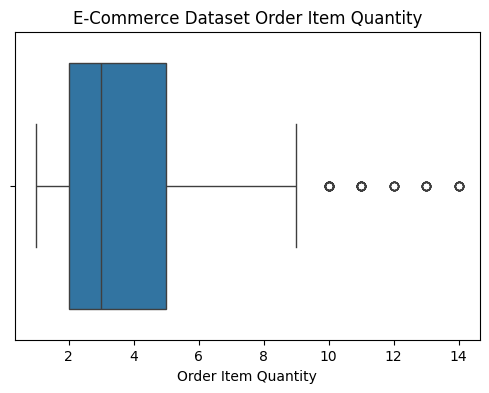

In [9]:
plt.figure(figsize=(6,4))
sns.boxplot(x=ecommerce["Quantity"])
plt.title("E-Commerce Dataset Order Item Quantity")
plt.xlabel("Order Item Quantity")
plt.show()

# Filter unrealistic quantities
ecommerce = ecommerce[ecommerce["Quantity"] < 100]

In [10]:
instacart.columns

Index(['order_id', 'product_id', 'reordered', 'product_name', 'aisle_id',
       'department_id', 'aisle', 'department', 'user_id', 'eval_set',
       'order_number', 'order_dow', 'order_hour_of_day',
       'days_since_prior_order'],
      dtype='str')

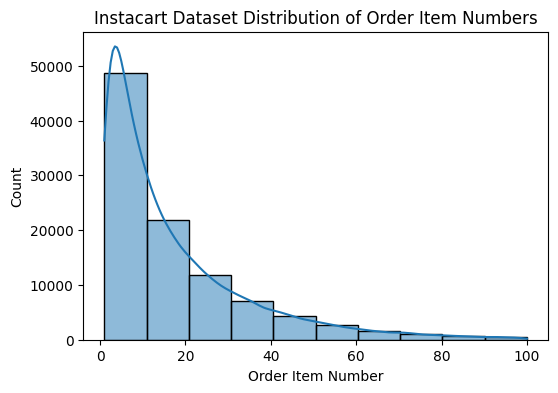

In [11]:
plt.figure(figsize=(6,4))
sns.histplot(instacart["order_number"], bins=10, kde=True)
plt.title("Instacart Dataset Distribution of Order Item Numbers")
plt.xlabel("Order Item Number")
plt.show()

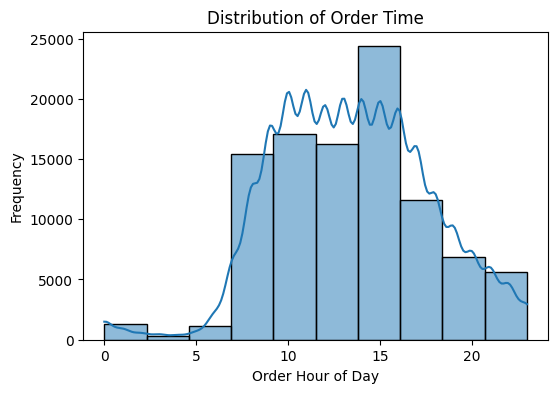

In [12]:
plt.figure(figsize=(6,4))
sns.histplot(instacart["order_hour_of_day"], bins=10, kde=True)
plt.title("Distribution of Order Time")
plt.xlabel("Order Hour of Day")
plt.ylabel("Frequency")
plt.show()

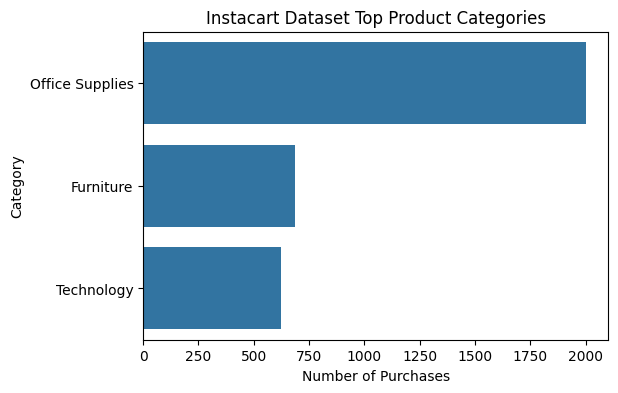

In [13]:
plt.figure(figsize=(6,4))

category_counts = ecommerce["Category"].value_counts().head(10)

sns.barplot(x=category_counts.values, y=category_counts.index)

plt.title("Instacart Dataset Top Product Categories")
plt.xlabel("Number of Purchases")
plt.ylabel("Category")

plt.show()

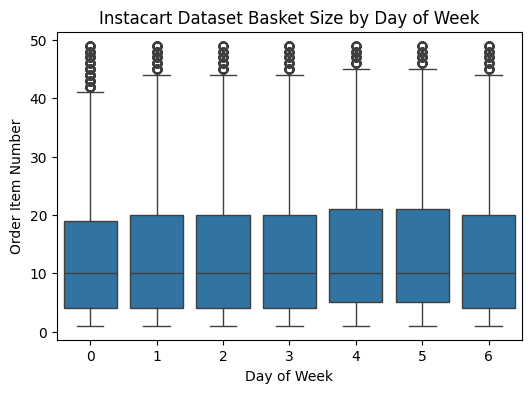

In [14]:
basket_crop = instacart[instacart["order_number"]<50]

plt.figure(figsize=(6,4))

sns.boxplot(
    x=basket_crop["order_dow"],
    y=basket_crop["order_number"]
)

plt.title("Instacart Dataset Basket Size by Day of Week")
plt.xlabel("Day of Week")
plt.ylabel("Order Item Number")

plt.show()

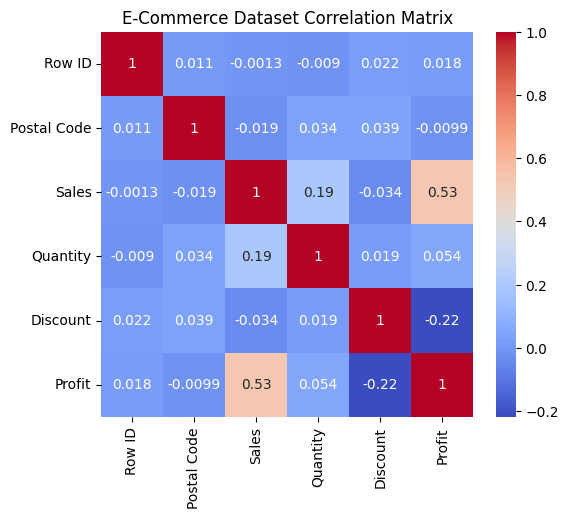

In [15]:
numeric_data = ecommerce.select_dtypes(include=[np.number])

plt.figure(figsize=(6,5))

sns.heatmap(
    numeric_data.corr(),
    annot=True,
    cmap="coolwarm"
)

plt.title("E-Commerce Dataset Correlation Matrix")

plt.show()

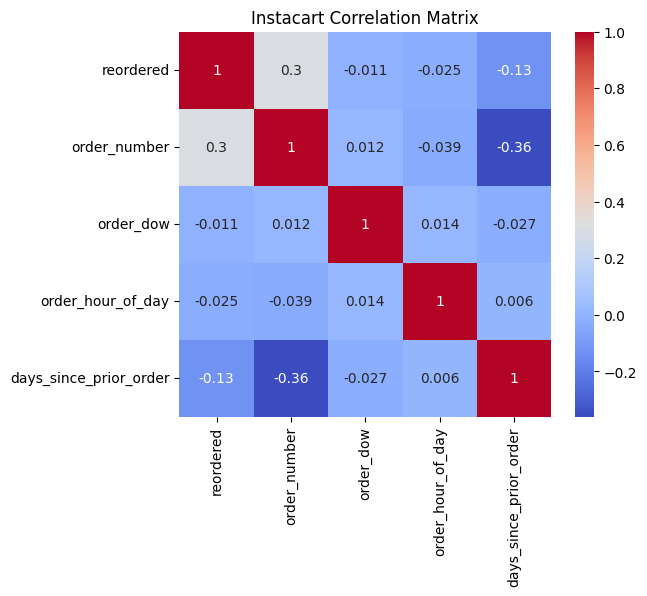

In [18]:
insta = instacart.drop(["order_id", "product_id", "department_id", "user_id", "aisle_id"], axis=1)

insta_numeric_data = insta.select_dtypes(include=[np.number])

plt.figure(figsize=(6,5))

sns.heatmap(
    insta_numeric_data.corr(),
    annot=True,
    cmap="coolwarm"
)

plt.title("Instacart Correlation Matrix")

plt.show()

In [20]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

basket_counts = instacart.groupby("order_id").size()

basket_df = pd.DataFrame({
    "order_id": basket_counts.index,
    "basket_size": basket_counts.values
})

basket_orders = instacart.merge(basket_df, on="order_id")

customer_features = basket_orders.groupby("user_id").agg({
    "basket_size":"mean",
    "order_id":"count"
}).reset_index()

customer_features.columns = ["user_id","avg_basket_size","purchase_frequency"]

scaler = StandardScaler()

scaled = scaler.fit_transform(customer_features[["avg_basket_size","purchase_frequency"]])

kmeans = KMeans(n_clusters=4, random_state=42)

customer_features["cluster"] = kmeans.fit_predict(scaled)

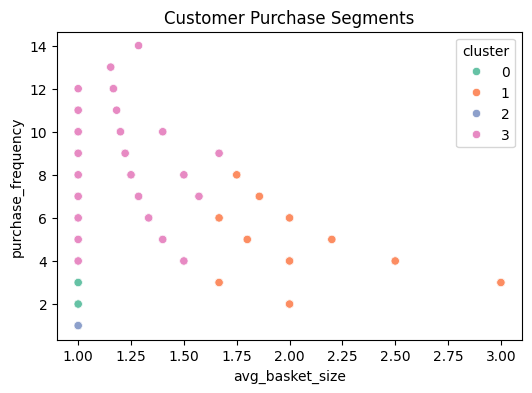

In [21]:
plt.figure(figsize=(6,4))

sns.scatterplot(
    data=customer_features,
    x="avg_basket_size",
    y="purchase_frequency",
    hue="cluster",
    palette="Set2"
)

plt.title("Customer Purchase Segments")

plt.show()

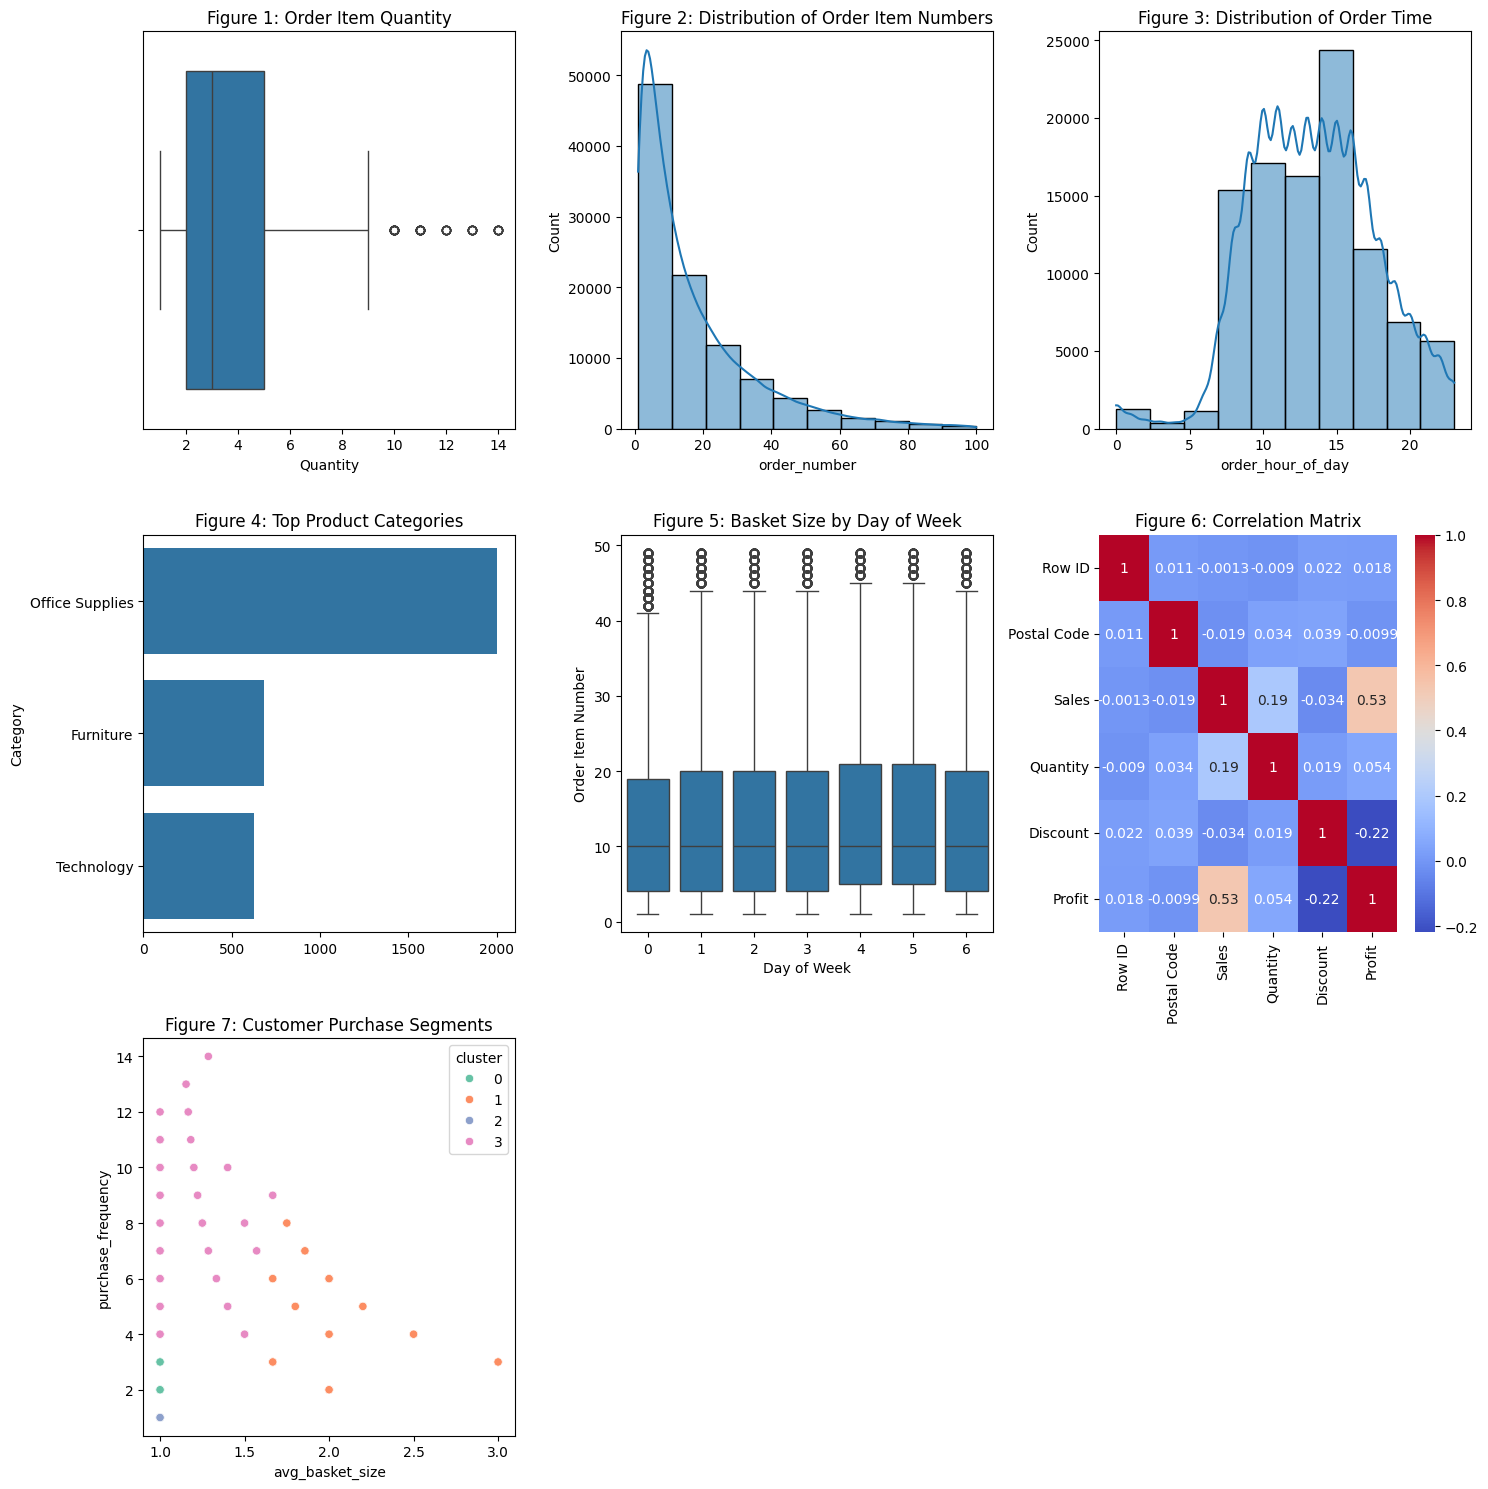

In [23]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Filter unrealistic quantities
ecommerce = ecommerce[ecommerce["Quantity"] < 100]

numeric_data = ecommerce.select_dtypes(include=[np.number])
basket_crop = instacart[instacart["order_number"] < 50]
category_counts = ecommerce["Category"].value_counts().head(10)

fig, axes = plt.subplots(3, 3, figsize=(15,15))

# 1. Quantity boxplot
sns.boxplot(x=ecommerce["Quantity"], ax=axes[0,0])
axes[0,0].set_title("Figure 1: Order Item Quantity")

# 2. Order number histogram
sns.histplot(instacart["order_number"], bins=10, kde=True, ax=axes[0,1])
axes[0,1].set_title("Figure 2: Distribution of Order Item Numbers")

# 3. Order hour histogram
sns.histplot(instacart["order_hour_of_day"], bins=10, kde=True, ax=axes[0,2])
axes[0,2].set_title("Figure 3: Distribution of Order Time")

# 4. Category bar chart
sns.barplot(x=category_counts.values, y=category_counts.index, ax=axes[1,0])
axes[1,0].set_title("Figure 4: Top Product Categories")

# 5. Basket size by day boxplot
sns.boxplot(
    x=basket_crop["order_dow"],
    y=basket_crop["order_number"],
    ax=axes[1,1]
)
axes[1,1].set_title("Figure 5: Basket Size by Day of Week")
axes[1,1].set_xlabel("Day of Week")
axes[1,1].set_ylabel("Order Item Number")

# 6. Correlation heatmap
sns.heatmap(
    numeric_data.corr(),
    annot=True,
    cmap="coolwarm",
    ax=axes[1,2]
)
axes[1,2].set_title("Figure 6: Correlation Matrix")

# 7. Customer cluster scatterplot
sns.scatterplot(
    data=customer_features,
    x="avg_basket_size",
    y="purchase_frequency",
    hue="cluster",
    palette="Set2",
    ax=axes[2,0]
)
axes[2,0].set_title("Figure 7: Customer Purchase Segments")

# Hide unused subplot spaces
axes[2,1].axis("off")
axes[2,2].axis("off")

plt.tight_layout()

plt.savefig("milestone_figures.png", dpi=300)

plt.show()
